In [222]:
import numpy as np 
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [223]:
df=pd.read_csv(r"C:\Users\halku\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [224]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [225]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [226]:
df['customerID'].value_counts()              #we can drop it

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

In [227]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [228]:
cols=['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

In [229]:
for i in cols:
    print(df[i].value_counts())

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    15

In [230]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [231]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.6,1


In [232]:
cat_cols=['PaymentMethod','Contract','StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','InternetService','MultipleLines']

In [233]:
df=pd.get_dummies(df, columns=cat_cols,drop_first=True,dtype=int)

In [234]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_No internet service,DeviceProtection_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,0,1,0,0,0,1,0,0,0,0
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,1,0,1,0,0,0,0
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,0,1,0,0,0,1,0,0,1,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,1,84.80,1990.5,...,0,1,0,0,0,1,0,0,0,1
7039,2234-XADUH,0,0,1,1,72,1,1,103.20,7362.9,...,0,1,0,1,0,0,1,0,0,1
7040,4801-JZAZL,0,0,1,1,11,0,1,29.60,346.45,...,0,0,0,0,0,1,0,0,1,0
7041,8361-LTMKD,1,1,1,0,4,1,1,74.40,306.6,...,0,0,0,0,0,0,1,0,0,1


In [235]:
df.drop(columns=['customerID'], inplace=True)

In [236]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_No internet service,DeviceProtection_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,0,1,0,0,0,1,0,0,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,1,0,1,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,0,0,0,1,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.5,0,...,0,1,0,0,0,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.9,0,...,0,1,0,1,0,0,1,0,0,1
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,1,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.6,1,...,0,0,0,0,0,0,1,0,0,1


In [237]:
(df['TotalCharges'] == ' ').sum()


np.int64(11)

In [238]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [239]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [240]:
df['TotalCharges'].dtype

dtype('float64')

In [241]:
X=df.drop('Churn', axis=1)
y=df['Churn']

In [242]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),...,DeviceProtection_No internet service,DeviceProtection_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,1,0,0,0,0
2,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,1,0,1,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,0,0,0,1,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,0,1,0,0,0,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,1,...,0,1,0,1,0,0,1,0,0,1
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,1,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,0,...,0,0,0,0,0,0,1,0,0,1


In [243]:
from sklearn.model_selection import train_test_split


In [244]:
X_train, X_test, y_train, y_test = train_test_split  ( X, y, test_size=0.20, random_state=42, stratify=y) 

In [245]:
# Fill missing values with the median of the training set
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(X_train['TotalCharges'].median())

# Use the same median to fill the test set
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_train['TotalCharges'].median())

In [246]:
from sklearn.preprocessing import StandardScaler

In [247]:
columns=['tenure','MonthlyCharges',	'TotalCharges',]
scaler=StandardScaler()
X_train[columns]=scaler.fit_transform(X_train[columns])
X_test[columns]=scaler.transform(X_test[columns])


In [248]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),...,DeviceProtection_No internet service,DeviceProtection_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.263290,0,...,0,1,0,0,0,0,0,0,1,0
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.504815,0,...,0,0,0,0,0,1,1,0,0,0
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.751214,0,...,0,0,0,1,0,1,0,0,1,0
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.173700,1,...,0,1,0,1,0,0,0,0,0,0
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.990851,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,1.567778,1,0,1.470695,2.373711,0,...,0,1,0,1,0,0,1,0,0,1
6227,1,0,0,0,-1.240918,1,0,-0.626504,-0.975133,0,...,0,0,0,0,0,0,0,0,0,0
4673,0,1,0,0,-0.304686,1,1,1.256662,0.157569,0,...,0,0,0,1,0,1,1,0,0,1
2710,0,0,1,0,-0.345392,1,0,-1.477661,-0.798435,1,...,1,0,1,0,1,0,0,1,0,0


In [249]:
from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0])

In [250]:
per=Perceptron(max_iter=1000, random_state=42)
per.fit(X_train,y_train)

Perceptron(random_state=42)

In [251]:
y_pred_percep=per.predict(X_test)

In [252]:
accuracy_score(y_test,y_pred_percep)

0.7508871540099361

In [253]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),...,DeviceProtection_No internet service,DeviceProtection_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.263290,0,...,0,1,0,0,0,0,0,0,1,0
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.504815,0,...,0,0,0,0,0,1,1,0,0,0
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.751214,0,...,0,0,0,1,0,1,0,0,1,0
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.173700,1,...,0,1,0,1,0,0,0,0,0,0
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.990851,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,1.567778,1,0,1.470695,2.373711,0,...,0,1,0,1,0,0,1,0,0,1
6227,1,0,0,0,-1.240918,1,0,-0.626504,-0.975133,0,...,0,0,0,0,0,0,0,0,0,0
4673,0,1,0,0,-0.304686,1,1,1.256662,0.157569,0,...,0,0,0,1,0,1,1,0,0,1
2710,0,0,1,0,-0.345392,1,0,-1.477661,-0.798435,1,...,1,0,1,0,1,0,0,1,0,0


In [254]:
model = Sequential([
    Dense(64,input_dim = 30,activation='relu'),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

In [255]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [256]:
from tensorflow.keras.callbacks import EarlyStopping  #used early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [257]:
history = model.fit(X_train,y_train,
                    epochs = 100,batch_size= 32, validation_data = (X_test, y_test),callbacks=[early_stop])

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7563 - loss: 0.4950 - val_accuracy: 0.7871 - val_loss: 0.4342
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7902 - loss: 0.4427 - val_accuracy: 0.7970 - val_loss: 0.4281
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7975 - loss: 0.4346 - val_accuracy: 0.7970 - val_loss: 0.4228
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7998 - loss: 0.4316 - val_accuracy: 0.7977 - val_loss: 0.4238
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8040 - loss: 0.4270 - val_accuracy: 0.7991 - val_loss: 0.4200
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8056 - loss: 0.4228 - val_accuracy: 0.7984 - val_loss: 0.4196
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8058 - loss: 0.4201 - val_accuracy: 0.8013 - val_loss: 0.4210
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8012 - loss: 0.4213 - val_accu

In [258]:
print(y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


ML ALGORITHMS

In [259]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [260]:
models={
    "logistic Regression": LogisticRegression(),
    "KNN":  KNeighborsClassifier(),
    "Navie Bayes":GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier()
}

In [261]:
result=[]

In [262]:
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        'models': name,
        'Accuracy': round(acc, 4),
        'f1 score': round(f1, 4)
    })

In [263]:
result

[{'models': 'logistic Regression', 'Accuracy': 0.8055, 'f1 score': 0.604},
 {'models': 'KNN', 'Accuracy': 0.763, 'f1 score': 0.5523},
 {'models': 'Navie Bayes', 'Accuracy': 0.6558, 'f1 score': 0.5719},
 {'models': 'SVM', 'Accuracy': 0.7949, 'f1 score': 0.5547},
 {'models': 'Decision Tree', 'Accuracy': 0.7339, 'f1 score': 0.4953}]

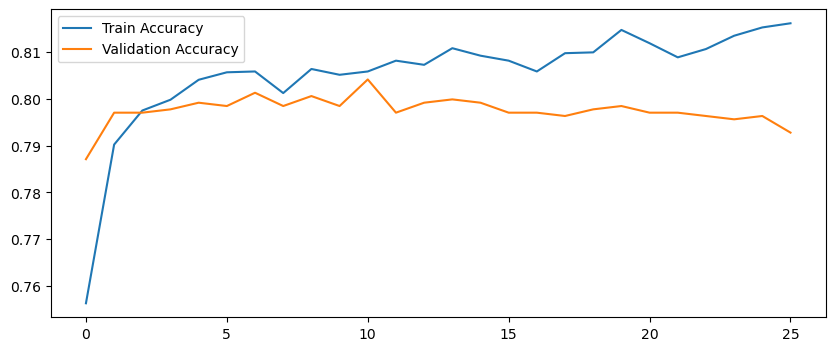

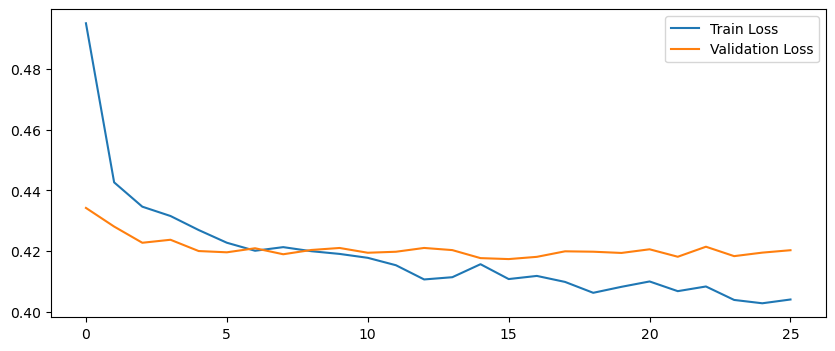

In [264]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()